In [11]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

groq_key = os.environ["GROQ_API_KEY"]
os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGCHAIN_API_KEY')

llm = ChatGroq(model="openai/gpt-oss-20b", groq_api_key=groq_key)

In [12]:
from typing_extensions import TypedDict
from langgraph.graph import START, END, StateGraph
from IPython.display import Image, display

class State(TypedDict):
    topic:str
    story_premise:str
    characters:str
    style:str
    final_story:str

def generate_story(state:State):
    msg = llm.invoke(f"Write a one line story premise on the topic about {state['topic']}")
    return {"story_premise":msg.content}

def make_characters(state:State):
    msg = llm.invoke(f"Make characters, give their name and overall traits suitable for this topic: {state['topic']}")
    return {"characters":msg.content}

def style_maker(state:State):
    msg = llm.invoke(f"Develop a style of storytelling for the given topic, like linear timeline, or hoping in time lines, or any other... you're free to use your creativity: {state['topic']}")
    return {"style":msg.content}

def make_final_story(state:State):
    msg = llm.invoke(
        f"""
        Make a proper story using these elements:

        Story Premise: {state['story_premise']}
        Characters: {state['characters']}
        Style of storytelling: {state['style']}
        """
    )
    return {"final_story": msg.content}

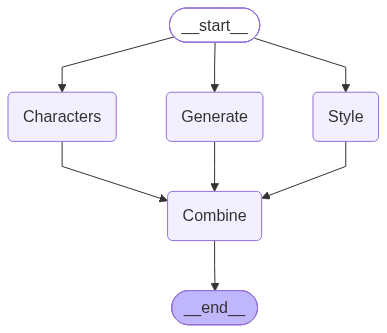

In [13]:
graph = StateGraph(State)

graph.add_node("Generate", generate_story)
graph.add_node("Characters", make_characters)
graph.add_node("Style", style_maker)
graph.add_node("Combine", make_final_story)

graph.add_edge(START, "Generate")
graph.add_edge(START, "Characters")
graph.add_edge(START, "Style")
graph.add_edge("Style", "Combine")
graph.add_edge("Characters", "Combine")
graph.add_edge("Generate", "Combine")

graph.add_edge("Combine", END)

graph_build = graph.compile()
display(Image(graph_build.get_graph().draw_mermaid_png()))

In [14]:
result = graph_build.invoke(
    {"topic" : "College Love story"}
)

In [15]:
result

{'topic': 'College Love story',
 'story_premise': 'A shy literature major and a charismatic physics prodigy fall for each other in a campus debate club, but their secret rivalry threatens to derail their future.',
 'characters': 'Below is a “ready‑to‑write” cast for a contemporary college love story.  Each character is given a name, a short descriptor of their major or role on campus, and a handful of core personality traits that will drive the narrative and make the romantic beats feel authentic.\n\n| # | Name | Role/Background | Key Traits | How They Fit the Love Story |\n|---|------|----------------|------------|-----------------------------|\n| **1** | **Avery “Ava” Patel** | Female, sophomore, Biology major | Curious, resilient, quietly observant, a bit introverted, fiercely loyal | The protagonist who falls for the new transfer student. Her scientific curiosity mirrors her growing emotional curiosity. |\n| **2** | **Liam O’Connor** | Male, junior, Mechanical Engineering major | C